# **SET UP**

In [1]:
# Need set up code
import sys
from pathlib import Path
import importlib.util

INPUT_ROOT = Path("/kaggle/input")
WORKING = Path("/kaggle/working")

HELPER_FILES = ["feature_extract.py", "load_data.py", "evaluate.py", "baseline_models.py"]
helper_dir = None
helper_dir = None
for p in INPUT_ROOT.rglob("feature_extract.py"):
    if all((p.parent / f).exists() for f in HELPER_FILES):
        helper_dir = p.parent
        break
helper_link = WORKING / "helpers"
if helper_link.is_symlink() or helper_link.exists():
    if helper_link.is_symlink():
        helper_link.unlink()
if not helper_link.exists():
    helper_link.symlink_to(helper_dir)
if str(WORKING) not in sys.path:
    sys.path.insert(0, str(WORKING))
print("Helper dir   :", helper_dir)

def _find(pattern, kind):
    hits = list(INPUT_ROOT.rglob(pattern))
    if not hits:
        raise FileNotFoundError(f"{kind} ('{pattern}') not found under /kaggle/input")
    return str(hits[0])

PLATES_PATH     = _find("PB2002_plates.json", "plates geojson")
TRAIN_DATA_PATH = _find("training_trajectories_full", "train folder")
TEST_DATA_PATH  = _find("test_seq", "test folder")

print("PLATES_PATH    :", PLATES_PATH)
print("TRAIN_DATA_PATH:", TRAIN_DATA_PATH)
print("TEST_DATA_PATH :", TEST_DATA_PATH)

n_train_seq = len(list(Path(TRAIN_DATA_PATH).glob("X_*.csv")))
n_test_seq  = len(list(Path(TEST_DATA_PATH).glob("X_*.csv")))
print(f"Found {n_train_seq} train X_*.csv, {n_test_seq} test X_*.csv")

for pkg in ["torch", "geopandas", "lightgbm", "xgboost"]:
    print(f"{pkg:10s}:", "OK" if importlib.util.find_spec(pkg) else "MISSING")

Helper dir   : /kaggle/input/datasets/markcjpark/helpers
PLATES_PATH    : /kaggle/input/datasets/markcjpark/plates/plate_mainshock_analysis/tectonicplates-master/GeoJSON/PB2002_plates.json
TRAIN_DATA_PATH: /kaggle/input/datasets/markcjpark/eq-data/cleaned_data/training_trajectories_full
TEST_DATA_PATH : /kaggle/input/datasets/markcjpark/eq-data/cleaned_data/test_seq
Found 3928 train X_*.csv, 20 test X_*.csv
torch     : OK
geopandas : OK
lightgbm  : OK
xgboost   : OK


# Import necessary Files

In [2]:
import sys
from pathlib import Path
import importlib.util
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam
from tqdm import tqdm
import joblib
import helpers.feature_extract as fx
import helpers.load_data as ld
import helpers.evaluate as eh
import helpers.baseline_models as bsm


# Extract Features + Define Settings

In [3]:
# File path
WINDOWS = {"T1": (0.0, 1.0), # 24 hours within
           "T2": (1.0, 3.0), # 24-72 hours
           "T3": (3.0, 7.0)} # 72 -168 hours
PLATE_MIN_COUNT = 30
# FEATURE COLS
FEATURE_COLS = ["log_time_gap_days",
                "Depth", "Mag", "Lat", "Lon",
                "dx_km", "dy_km", "log_flat_dist_km",
                "rel_time_diff", "rel_mag_diff", "rel_depth_diff"]

SCALE_COLS = ["log_time_gap_days",
                "Depth", "Mag","Lat", "Lon",
                "dx_km", "dy_km", "log_flat_dist_km",
                "rel_time_diff", "rel_mag_diff", "rel_depth_diff"]

**Feature Extraction Functions**

In [4]:
def mainshock_ref(df_X):
    "Mainshock Reference Function"
    df_X = df_X.copy()
    df_X["datetime"] = pd.to_datetime(df_X["Date"].astype(str) + " " + df_X["Time"].astype(str),
                                      format="%Y-%m-%d %H:%M:%S")
    df_X = df_X.sort_values("datetime").reset_index(drop=True)
    idx = fx.find_mainshock_idx(df_X)
    row = df_X.loc[idx]
    return {"datetime": row["datetime"],
            "mag": float(row["Mag"])}
    
def encode_Y_one(df_X, df_Y):
    "One sequence: raw T1/T2/T3 DataFrame ==> [3, 2] (delta_mag, norm_time)."
    mainshock = mainshock_ref(df_X)
    df_Y = df_Y.copy()
    df_Y["datetime"] = pd.to_datetime(df_Y["Date"] + " " + df_Y["Time"], format="%Y-%m-%d %H:%M:%S")
    df_Y["Mag"] = pd.to_numeric(df_Y["Mag"])
    Y = np.zeros((3, 2), dtype=np.float64)

    for i, key in enumerate(("T1", "T2", "T3")):
        row = df_Y.loc[df_Y["T"] == i + 1].iloc[0]
        w0, w1 = WINDOWS[key]
        dt_days = (row["datetime"] - mainshock["datetime"]).total_seconds() / (60 * 60*24)
        Y[i, 0] = row["Mag"] - mainshock["mag"] # delta_mag
        Y[i, 1] = (dt_days - w0) / (w1 - w0) # norm_time
    return Y


def decode_predictions(pred,df_X):
    "Inverse of encode_Y_one, Model output [3,2] + raw X ===> Dataframe with predicted Time and predicted mag in abs unit"
    pred = np.asarray(pred).reshape(3, 2)
    mainshock = mainshock_ref(df_X)
    rows = []
    for i, key in enumerate(("T1", "T2", "T3")):
        w0, w1 = WINDOWS[key]
        norm_time = np.clip(float(pred[i, 1]), 0.0, 1.0)
        days = w0 + norm_time * (w1 - w0)
        predicted_time = mainshock["datetime"] + pd.to_timedelta(days, unit="D")
        rows.append({
            "T": i + 1,
            "predicted_time": predicted_time.strftime("%Y%m%d%H%M%S"),
            "predicted_mag": mainshock["mag"] + float(pred[i, 0]),
        })
    return pd.DataFrame(rows)


def build_dfX(df_X_list,valid_ids=None,plate_group_by_id=None,
              plate_vec=None):
    if valid_ids is None:
        valid_ids = list(range(len(df_X_list)))

    engineered = []

    for df, seq_id in zip(df_X_list, valid_ids):
        df_eng = fx.extract_oneX(df,plate_group = plate_group_by_id.get(seq_id, "Other"), plate_vec = plate_vec)
        engineered.append(df_eng)
    feature_cols = list(FEATURE_COLS)
    feature_cols += [f"plate_{p}" for p in plate_vec]
    return engineered, feature_cols


def build_XY_train(df_X_list, df_Y_list, valid_ids=None, scaler_path=None):
    scaler_path = Path(scaler_path)
    scaler_path.parent.mkdir(parents=True, exist_ok=True)
    if valid_ids is None:
        valid_ids = list(range(len(df_X_list)))

    plate_group_by_id, plate_vec, _, _, _ = fx.fit_plate_groups(df_X_list=df_X_list,valid_ids=valid_ids,
                                                                    plates_path=PLATES_PATH,
                                                                    min_count=PLATE_MIN_COUNT)

    engineered, feature_cols = build_dfX(df_X_list=df_X_list,
                                                      valid_ids=valid_ids,
                                                      plate_group_by_id=plate_group_by_id,
                                                      plate_vec=plate_vec)

    scaler, medians = fx.fit_scalar(engineered, SCALE_COLS)
    scaled = [fx.scale_seq(df, scaler, medians, SCALE_COLS) for df in engineered]
    X_arrays = [df[feature_cols].astype(np.float64).values for df in scaled]
    Y_arrays = [encode_Y_one(x, y) for x, y in zip(df_X_list, df_Y_list)]

    with open(scaler_path, "wb") as f:
        pickle.dump({
            "scaler": scaler,
            "medians": medians,
            "feature_cols": feature_cols,
            "scale_cols": SCALE_COLS,
            "plate_vec": plate_vec,
            "plates_path": PLATES_PATH,
            "plate_min_count": PLATE_MIN_COUNT,
        }, f)

    return X_arrays, Y_arrays, feature_cols

def build_XY_test( df_X_list, df_Y_list=None, valid_ids=None, scaler_path=None):
    scaler_path = Path(scaler_path)
    with open(scaler_path, "rb") as f:
        s = pickle.load(f)

    if valid_ids is None:
        valid_ids = list(range(len(df_X_list)))

    use_magtype = s.get("use_magtype", False)
    magtype_vec = s.get("magtype_vec", [])
    plate_vec = s.get("plate_vec", [])

    plates = fx.load_plate_polygons(s["plates_path"])
    plate_group_by_id, plate_table = fx.transform_plate_groups(df_X_list=df_X_list,
                                                                valid_ids=valid_ids,
                                                                plates=plates, train_plate_vec=plate_vec)

    engineered, _, = build_dfX(df_X_list=df_X_list,
                               valid_ids=valid_ids,
                               plate_group_by_id=plate_group_by_id,plate_vec=plate_vec)

    scaled = [fx.scale_seq(df, s["scaler"], s["medians"], s["scale_cols"]) for df in engineered]
    X_arrays = [df[s["feature_cols"]].astype(np.float64).values for df in scaled]

    if df_Y_list is None:
        return X_arrays, s["feature_cols"]
    Y_arrays = [encode_Y_one(x, y) for x, y in zip(df_X_list, df_Y_list)]
    return X_arrays, Y_arrays, s["feature_cols"]

# Load & Save Extracted Features

In [5]:
cache_name = "n_all"
cache_dir = Path(f"/kaggle/working/cache/{cache_name}")
cache_dir.mkdir(parents=True, exist_ok=True)
max_obs = None
min_mag = 3.0
scaler_path = cache_dir / "scaler.pkl"
cache_path = cache_dir / f"features_minmag{min_mag}_maxobs{max_obs}.joblib"

df_X_list, df_Y_list, valid_ids = ld.load_raw_data(TRAIN_DATA_PATH, min_mag, max_obs, seed=123)
testX_raw, testY_raw, test_ids   = ld.load_raw_data(TEST_DATA_PATH,  min_mag, max_obs, seed=123)
print("# train:", len(df_X_list), "# test:", len(testX_raw))

# --- Truncate recent history BEFORE feature extraction (saves memory) ---
PRE_CAP = 300   # keep last 300 events per sequence; mainshock is the last row
df_X_cap     = [df.tail(PRE_CAP).reset_index(drop=True) for df in df_X_list]
testX_raw_cap = [df.tail(PRE_CAP).reset_index(drop=True) for df in testX_raw]

import gc
del df_X_list 
gc.collect()
print("pre-capped. max train rows now:", max(len(d) for d in df_X_cap))

Using shuffled IDs with seed = 123
# of skipped ids 0
# of valid T 3928
Using shuffled IDs with seed = 123
# of skipped ids 0
# of valid T 20
# train: 3928 # test: 20
pre-capped. max train rows now: 300


In [6]:
import joblib, gc

X_arrays, Y_arrays, feature_cols = build_XY_train(df_X_cap, df_Y_list, scaler_path=str(scaler_path))
print("train dim:", X_arrays[0].shape[1])

testX_array, testY_array, test_feature_cols = build_XY_test(testX_raw_cap, testY_raw, scaler_path=str(scaler_path))
assert feature_cols == test_feature_cols, "feature mismatch"

cache = {"valid_ids": valid_ids, "test_ids": test_ids,
         "X_arrays": X_arrays, "Y_arrays": Y_arrays,
         "testX_array": testX_array, "testY_array": testY_array,
         "testY_raw": testY_raw, "testX_raw": testX_raw,   # full raw kept for decode/plot
         "feature_cols": feature_cols, "test_feature_cols": test_feature_cols,
         "min_mag": min_mag, "max_obs": max_obs, "scaler_path": str(scaler_path)}
gc.collect()
joblib.dump(cache, cache_path, compress=0)
print("saved", cache_path)

train dim: 41
saved /kaggle/working/cache/n_all/features_minmag3.0_maxobsNone.joblib


# Model Outline

In [7]:
class NeuralModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, output_size=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.attn = nn.Linear(hidden_size, 1)
        self.fc_T1 = nn.Linear(hidden_size, output_size)
        self.fc_T2 = nn.Linear(hidden_size, output_size)
        self.fc_T3 = nn.Linear(hidden_size, output_size)


    def attention(self, h):
        # h: [batch, seq_len, hidden]
        scores = self.attn(h).squeeze(-1)    
        weights = torch.softmax(scores, dim=-1)
        context = (weights.unsqueeze(-1) * h).sum(dim=1) 
        return context

    def forward(self, X):
        X = X.contiguous()
        h, _ = self.lstm(X)                     
        context = self.attention(h)       

        T1 = self.fc_T1(context)
        T2 = self.fc_T2(context)
        T3 = self.fc_T3(context)

        out = torch.stack([T1, T2, T3], dim=1)
        delta_mag = out[:, :, 0]
        norm_time = torch.sigmoid(out[:, :, 1])
        return torch.stack([delta_mag, norm_time], dim=-1)
    
    def fit(self, X_list, Y_list,device,save_path,
            lr=1e-3, epochs=20):
        """"Assume X_list and Y_list is already scaled"""
        if device is None:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.to(device)
        self.train()

        optimizer = Adam(self.parameters(), lr=lr)

        criterion = nn.L1Loss()
        loss_list = []

        best_loss = float("inf")
        for i in tqdm(range(epochs), desc='Training', disable=False):
            loss_batch = []

            for df_X, df_Y in zip(X_list, Y_list):

                X = torch.tensor(df_X, dtype=torch.float32, device=device).unsqueeze(0)
                Y = torch.tensor(df_Y, dtype=torch.float32, device=device).unsqueeze(0)

                Y_pred = self.forward(X)
                loss = criterion(Y_pred, Y)

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
                optimizer.step()
                loss_batch.append(loss.item())

            epoch_loss = float(np.mean(loss_batch))
            loss_list.append(epoch_loss)
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                if save_path is not None:
                    self.save(save_path)
            if i % 10 == 0:
                print(f'Epoch {i+1}/{epochs}, Loss: {loss_list[-1]:.4f}')
        return loss_list
    
    def predict_raw(self, df_X, device):
        """"
        Assume df_X is already scaled and changed to current features used
        Output will be change of Mag + normalized time diff
        """
        if device is None: device = next(self.parameters()).device
        self.eval()
        X = torch.tensor(df_X, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            pred = self.forward(X)
        return pred.squeeze(0).cpu().numpy()
    
    def predict(self, df_X, df_X_raw, device):
        return decode_predictions(self.predict_raw(df_X, device=device), df_X_raw)
    
    def save(self, path):
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        torch.save({"state_dict": self.state_dict(),
                    "input_size": self.lstm.input_size,
                    "hidden_size": self.lstm.hidden_size}, path)
        
    @classmethod
    def load(cls, path, device):
        ckpt = torch.load(path, map_location=device or "cpu", weights_only=True)
        model = cls(input_size=ckpt["input_size"], hidden_size=ckpt["hidden_size"])
        model.load_state_dict(ckpt["state_dict"])
        return model

In [8]:
save_path = Path("/kaggle/working/model/")
save_path.mkdir(parents=True, exist_ok=True)

cache = joblib.load(cache_path)
valid_ids = cache["valid_ids"]

testX_raw, testY_raw, test_ids = cache["testX_raw"], cache["testY_raw"], cache["test_ids"]
X_arrays = cache["X_arrays"]
Y_arrays = cache["Y_arrays"]
testX_array = cache["testX_array"]
testY_array = cache["testY_array"]

feature_cols = cache["feature_cols"]
test_feature_cols = cache["test_feature_cols"]

# Train Model & Evaluate

In [9]:
torch.backends.cudnn.enabled = True
MAX_LEN = 300
X_arrays   = [x[-MAX_LEN:] for x in X_arrays]
testX_array = [x[-MAX_LEN:] for x in testX_array]   # same cap on test
print("after cap — train max:", max(x.shape[0] for x in X_arrays),
      "| test max:", max(x.shape[0] for x in testX_array))

after cap — train max: 300 | test max: 217


In [10]:
# validation split (from training data)
val_frac = 0.15
n = len(X_arrays)
rng = np.random.default_rng(0)
perm = rng.permutation(n)
n_val = int(val_frac * n)
val_idx, tr_idx = perm[:n_val], perm[n_val:]

X_tr  = [X_arrays[i] for i in tr_idx]
Y_tr  = [Y_arrays[i] for i in tr_idx]
X_val = [X_arrays[i] for i in val_idx]
Y_val = [Y_arrays[i] for i in val_idx]
print(f"train: {len(X_tr)}  val: {len(X_val)}  test: {len(testX_array)}")

train: 3339  val: 589  test: 20


In [11]:
device_name = "cuda" if torch.cuda.is_available() else "cpu"
print(device_name)
lr = 1e-3
epochs = 150
hidden_size = 256
SAVE_MODEL_PATH = Path("/kaggle/working/model/neural_model.pt")
SAVE_EVAL_PATH = Path("/kaggle/working/results/")
model = NeuralModel(input_size=len(feature_cols),hidden_size=hidden_size,output_size=2)
model.fit(X_tr,Y_tr,device=device_name,lr=lr,epochs=epochs,  save_path = SAVE_MODEL_PATH)

print("Saved model to", SAVE_MODEL_PATH)

cuda


Training:   1%|          | 1/150 [00:35<1:26:59, 35.03s/it]

Epoch 1/150, Loss: 0.3560


Training:   7%|▋         | 11/150 [06:07<1:17:00, 33.24s/it]

Epoch 11/150, Loss: 0.3315


...

Epoch 131/150, Loss: 0.0824


Training:  94%|█████████▍| 141/150 [1:19:34<05:05, 33.92s/it]

Epoch 141/150, Loss: 0.0812


Training: 100%|██████████| 150/150 [1:24:37<00:00, 33.85s/it]

Saved model to /kaggle/working/model/neural_model.pt


In [12]:
def val_mae(model, X_list, Y_list, device):
    model.eval()
    # window widths in HOURS, in T1,T2,T3 order
    win_hours = np.array([(WINDOWS[k][1] - WINDOWS[k][0]) * 24.0 for k in ("T1","T2","T3")])  # [24,48,96]
    mag_err, time_err = [], []
    with torch.no_grad():
        for x, y in zip(X_list, Y_list):
            X = torch.tensor(x, dtype=torch.float32, device=device).unsqueeze(0).contiguous()
            p = model.forward(X).squeeze(0).cpu().numpy() 
            p_time = np.clip(p[:, 1], 0.0, 1.0)
            y_time = y[:, 1]
            mag_err.append(np.abs(p[:, 0] - y[:, 0]))
            time_err.append(np.abs(p_time - y_time) * win_hours)
    mag_err  = np.array(mag_err)
    time_err = np.array(time_err)
    print("validation MAE (physical units):")
    for t in range(3):
        print(f"  T{t+1}:  mag {mag_err[:, t].mean():.4f}   time {time_err[:, t].mean():.4f} h")
    print(f"  overall:  mag {mag_err.mean():.4f}   time {time_err.mean():.4f} h")
    return mag_err, time_err
    
val_mae(model, X_tr, Y_tr, device_name)
val_mae(model, X_val, Y_val, device_name)

validation MAE (physical units):
  T1:  mag 0.1038   time 1.3581 h
  T2:  mag 0.1031   time 2.6348 h
  T3:  mag 0.0966   time 5.2455 h
  overall:  mag 0.1012   time 3.0795 h
validation MAE (physical units):
  T1:  mag 0.5189   time 7.2038 h
  T2:  mag 0.5078   time 13.7983 h
  T3:  mag 0.4991   time 27.2725 h
  overall:  mag 0.5086   time 16.0915 h


(array([[1.30217114, 1.38925812, 0.46092277],
        [1.12455401, 0.04758805, 0.22616764],
        [0.63753635, 0.33914831, 0.23498476],
        ...,
        [0.44281166, 1.08578465, 0.56124805],
        [0.21118279, 0.98273333, 0.81026881],
        [0.35980132, 0.19026636, 0.22113872]], shape=(589, 3)),
 array([[15.37298761, 34.83363585, 56.70445889],
        [14.99208048,  8.54281841, 56.06204735],
        [ 1.55203264, 18.28246641, 11.02329036],
        ...,
        [13.77050734, 18.35054899, 47.97401195],
        [ 7.87457283, 16.84157413, 43.17865043],
        [ 2.43663257, 23.47741989,  9.3200959 ]], shape=(589, 3)))

         model  T  time_mae_hours  time_median_abs_err_hours   mag_mae  \
0  NeuralModel  1        4.497875                   2.637639  0.980142   
1  NeuralModel  2       16.417042                  14.596250  1.174103   
2  NeuralModel  3       42.993500                  49.667222  1.560241   

   mag_median_abs_err  
0            0.715260  
1            1.075466  
2            1.370351  


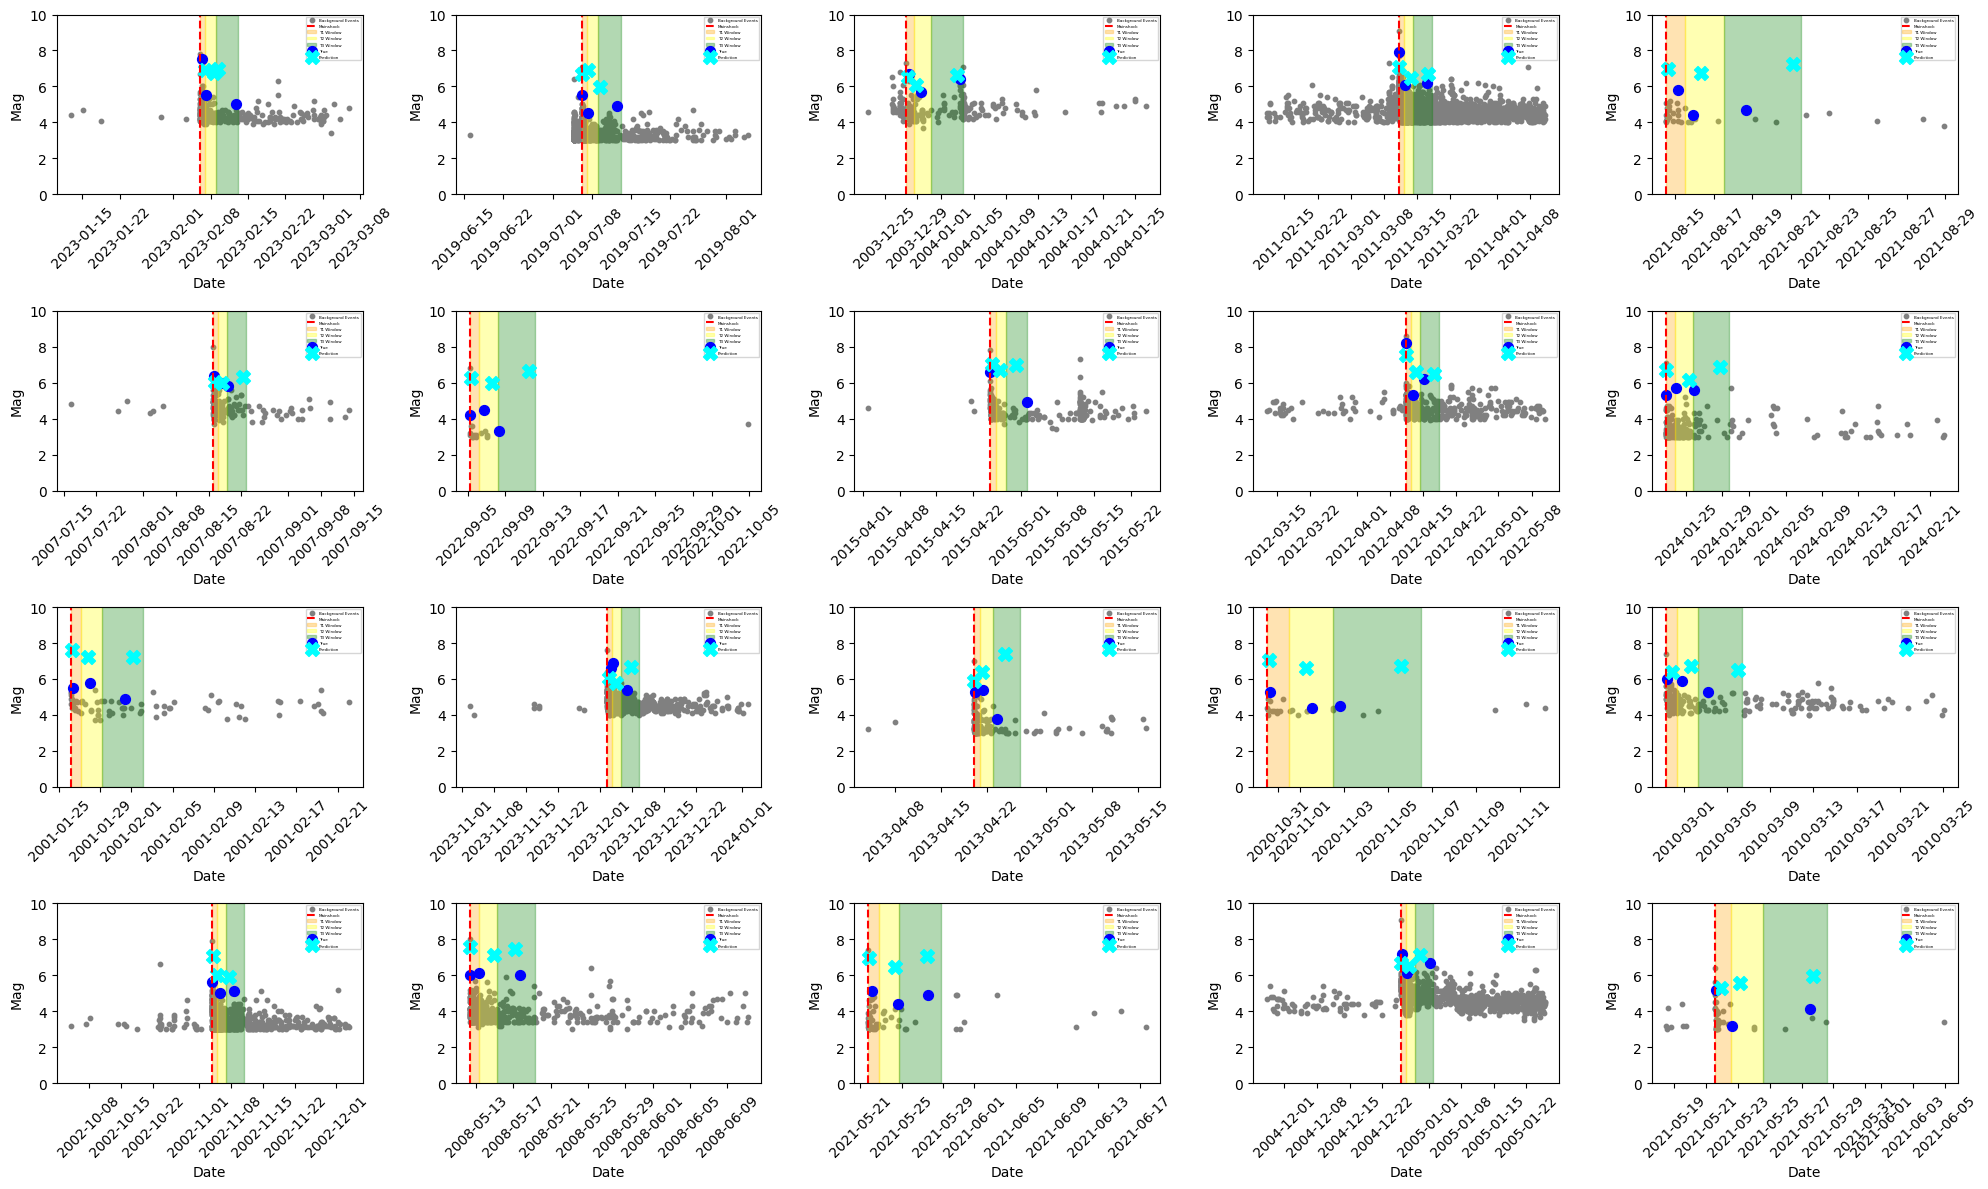

In [13]:
results = []
bg_path = "/kaggle/input/datasets/markcjpark/eq-data/cleaned_data/test_data"

for i in range(len(testX_array)):
    pred_df = model.predict(df_X=testX_array[i],df_X_raw=testX_raw[i],device=device_name)
    pred_df["ID"] = test_ids[i]
    results.append(pred_df)
results_df = pd.concat(results, axis=0, ignore_index=True)
results_df["model"] = "NeuralModel"
results_df = results_df[["model", "ID", "T", "predicted_time", "predicted_mag"]]
results_df.to_csv(save_path / "neural_predictions.csv", index=False)
neural_metrics_df = eh.evaluate_predictions(results_df=results_df,
                                         test_ids=test_ids,
                                         testY_raw=testY_raw,
                                         model_name="NeuralModel",
                                         save_path=save_path / "neural_metrics_by_prediction.csv")
neural_summary_by_T = eh.summarize_metrics(neural_metrics_df,
                                        save_dir=save_path,
                                        prefix="neural")
eh.plot_prediction_results(results_df=results_df,
                        test_ids=test_ids,
                        testX_raw=testX_raw,
                        testY_raw=testY_raw,
                        file_path=save_path,
                        file_name="neural",
                        bg_path = bg_path,
                        n_plot=20)

print(neural_summary_by_T)


Training LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

LightGBM train encoded MAE: 0.241729

Training XGBoost...
XGBoost train encoded MAE: 0.288668
Predicting LightGBM...
Predicting XGBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

      model  T  time_mae_hours  time_median_abs_err_hours   mag_mae  \
0  LightGBM  1        6.621361                   6.514306  0.856673   
1  LightGBM  2       11.664750                   9.896389  1.330280   
2  LightGBM  3       30.620556                  30.220000  1.468289   
3   XGBoost  1        6.993944                   7.740694  0.779526   
4   XGBoost  2       10.471014                   8.692778  1.328388   
5   XGBoost  3       28.785931                  29.005000  1.456389   

   mag_median_abs_err  
0            0.812185  
1            1.100606  
2            1.401842  
3            0.744519  
4            1.046812  
5            1.455383  


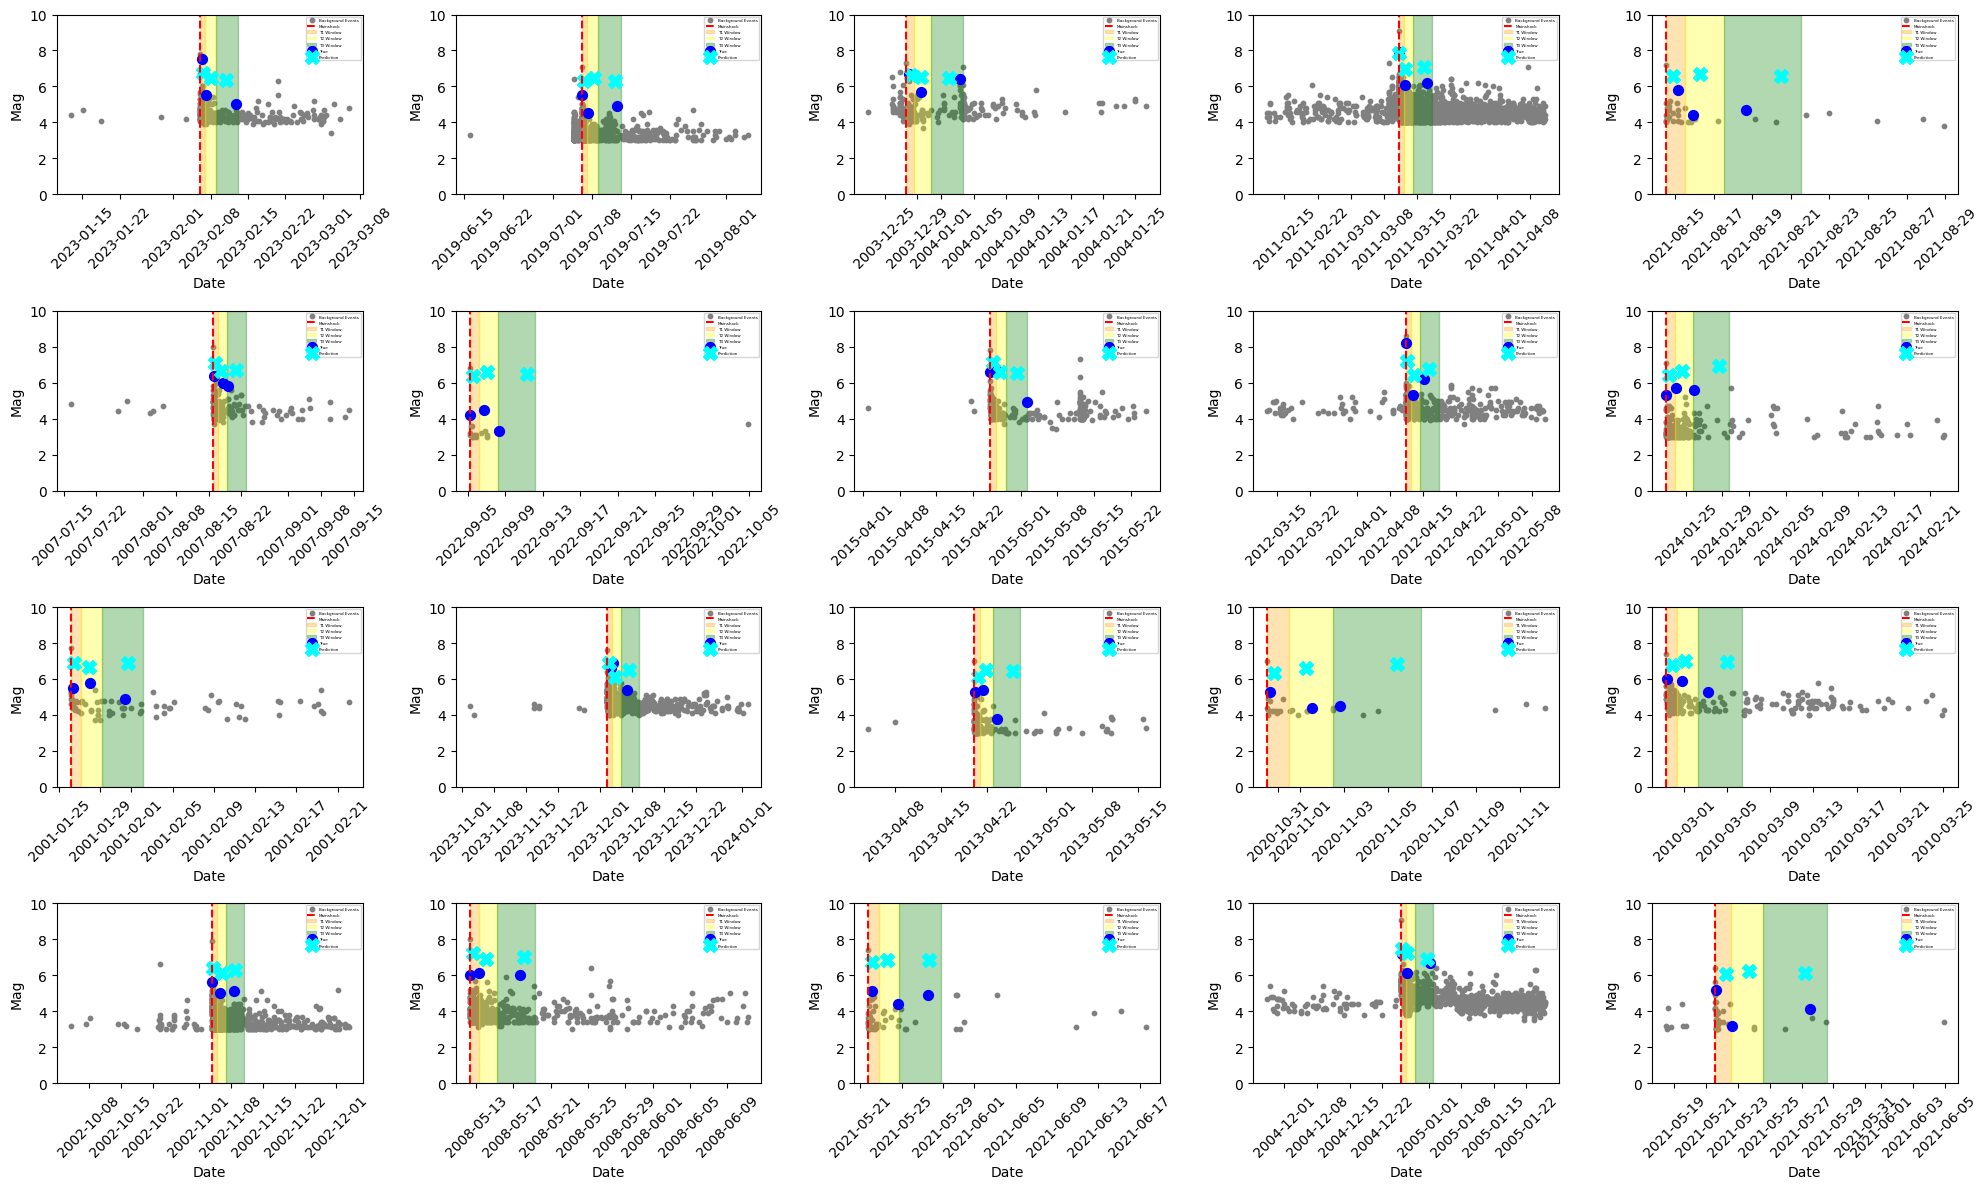

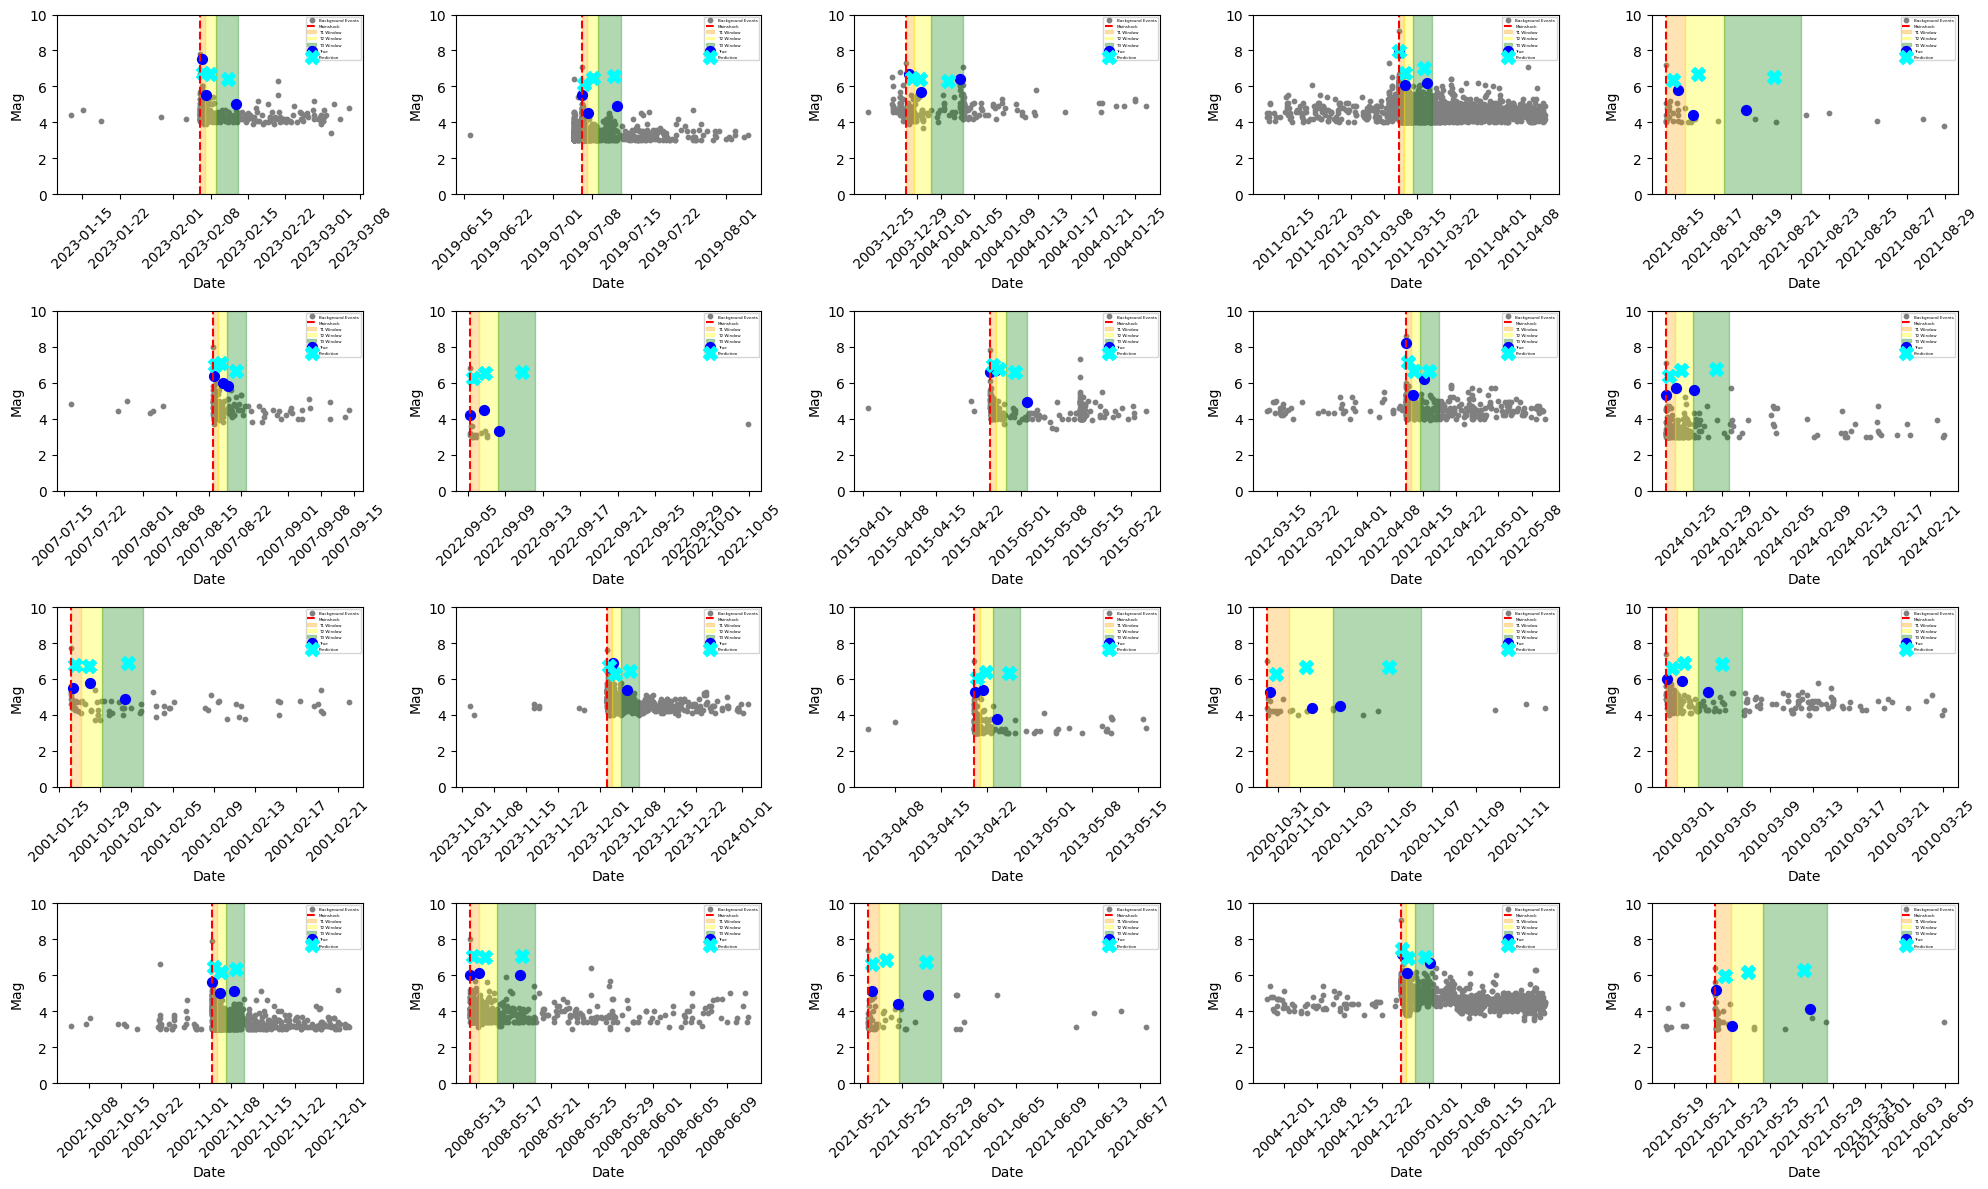

In [14]:
baseline_models, baseline_preds = bsm.fit_predict_baselines(X_arrays=X_arrays,
                                                        Y_arrays=Y_arrays,
                                                        testX_array=testX_array,
                                                        model_names=("LightGBM", "XGBoost"),
                                                        recent_k=50,
                                                        n_trees=500)

bsm.save_baseline_models(baseline_models,
                     save_path / "baseline_models.pkl")

baseline_results = []

for model_name, pred_tab in baseline_preds.items():
    for i in range(len(testX_array)):
        pred_i = pred_tab[i].reshape(3, 2)

        pred_df = decode_predictions(pred_i, testX_raw[i])
        pred_df["ID"] = test_ids[i]
        pred_df["model"] = model_name

        baseline_results.append(pred_df)

baseline_results_df = pd.concat(baseline_results, axis=0, ignore_index=True)
baseline_results_df = baseline_results_df[["model", "ID", "T", "predicted_time", "predicted_mag"]]

baseline_results_df.to_csv(save_path / "baseline_predictions.csv", index=False)

baseline_metrics_df = eh.evaluate_predictions(results_df=baseline_results_df,
                                           test_ids=test_ids,
                                           testY_raw=testY_raw,
                                           model_name=None,
                                           save_path=save_path / "baseline_metrics_by_prediction.csv")

baseline_summary_by_T = eh.summarize_metrics(baseline_metrics_df,
                                          save_dir=save_path,
                                          prefix="baseline")
for model_name in baseline_results_df["model"].unique():
    eh.plot_prediction_results(
        results_df=baseline_results_df[
            baseline_results_df["model"] == model_name
        ].copy(),
        test_ids=test_ids,
        testX_raw=testX_raw,
        testY_raw=testY_raw,
        file_name=model_name.lower(),
        file_path=save_path,
        n_plot=20,
        bg_path = bg_path
    )
print(baseline_summary_by_T)

# Extension: Ensemble Method

In [15]:
import numpy as np, torch
from sklearn.linear_model import LinearRegression

# ---------- 1. base-model predictions on VALIDATION (encoded space) ----------
def nn_preds(model, X_list, device):
    model.eval(); out = []
    with torch.no_grad():
        for x in X_list:
            X = torch.tensor(x, dtype=torch.float32, device=device).unsqueeze(0).contiguous()
            out.append(model.forward(X).squeeze(0).cpu().numpy())   # [3,2]
    return np.stack(out)                                            # [n,3,2]

def tree_preds(tree, X_list, recent_k=50):
    return tree.predict(bsm.make_tabular_X(X_list, recent_k=recent_k)).reshape(-1, 3, 2)

P_nn  = nn_preds(model, X_val, device_name)
P_lg  = tree_preds(baseline_models["LightGBM"], X_val)
P_xg  = tree_preds(baseline_models["XGBoost"],  X_val)
Y     = np.stack([np.asarray(y) for y in Y_val])                   # [n,3,2]
preds = {"NN": P_nn, "LGBM": P_lg, "XGB": P_xg}

def mae_table(P):  # per (T, target) MAE
    e = np.abs(P - Y)                       # [n,3,2]
    return e.mean(axis=0)                   # [3,2]: col0=mag, col1=time

# ---------- 2. SELECTION: per-(T,target) pick the best base model on val ----------
sel = np.zeros((3, 2))
sel_pred = np.zeros_like(P_nn)
routing = {}
for T in range(3):
    for tgt in range(2):   # 0=mag, 1=time
        errs = {n: np.abs(P[:, T, tgt] - Y[:, T, tgt]).mean() for n, P in preds.items()}
        best = min(errs, key=errs.get)
        routing[(T, tgt)] = best
        sel_pred[:, T, tgt] = preds[best][:, T, tgt]
sel_mae = np.abs(sel_pred - Y).mean(axis=0)

# ---------- 3. AVERAGE: equal-weight mean of all three (parameter-free) ----------
avg_pred = (P_nn + P_lg + P_xg) / 3.0
avg_mae  = np.abs(avg_pred - Y).mean(axis=0)

# ---------- 4. LINEAR STACK: one tiny regressor per (T,target), fit on val ----------
stack_pred = np.zeros_like(P_nn)
stack_coef = {}
for T in range(3):
    for tgt in range(2):
        Xm = np.column_stack([P_nn[:, T, tgt], P_lg[:, T, tgt], P_xg[:, T, tgt]])
        ym = Y[:, T, tgt]
        reg = LinearRegression().fit(Xm, ym)
        stack_pred[:, T, tgt] = reg.predict(Xm)
        stack_coef[(T, tgt)] = reg.coef_.round(2)
stack_mae = np.abs(stack_pred - Y).mean(axis=0)

# ---------- 5. report (encoded units) ----------
def show(name, m):
    print(f"{name:10s} | mag  T1 {m[0,0]:.3f} T2 {m[1,0]:.3f} T3 {m[2,0]:.3f} "
          f"(avg {m[:,0].mean():.3f}) | time T1 {m[0,1]:.3f} T2 {m[1,1]:.3f} T3 {m[2,1]:.3f} (avg {m[:,1].mean():.3f})")

print("=== VALIDATION MAE (encoded units) ===")
for n, P in preds.items(): show(n, mae_table(P))
print("-"*100)
show("Selection", sel_mae)
show("Average",   avg_mae)
show("LinStack",  stack_mae)
print("\nselection routing (T,target->model), target 0=mag 1=time:")
print({f"T{t+1}-{'mag' if g==0 else 'time'}": routing[(t,g)] for t in range(3) for g in range(2)})
print("\nstack coefficients [NN, LGBM, XGB] per cell:")
print({f"T{t+1}-{'mag' if g==0 else 'time'}": stack_coef[(t,g)].tolist() for t in range(3) for g in range(2)})


=== VALIDATION MAE (encoded units) ===
NN         | mag  T1 0.519 T2 0.508 T3 0.499 (avg 0.509) | time T1 0.300 T2 0.287 T3 0.284 (avg 0.291)
LGBM       | mag  T1 0.316 T2 0.302 T3 0.303 (avg 0.307) | time T1 0.180 T2 0.175 T3 0.173 (avg 0.176)
XGB        | mag  T1 0.379 T2 0.369 T3 0.367 (avg 0.372) | time T1 0.213 T2 0.207 T3 0.208 (avg 0.210)
----------------------------------------------------------------------------------------------------
Selection  | mag  T1 0.316 T2 0.302 T3 0.303 (avg 0.307) | time T1 0.180 T2 0.175 T3 0.173 (avg 0.176)
Average    | mag  T1 0.390 T2 0.376 T3 0.377 (avg 0.381) | time T1 0.220 T2 0.215 T3 0.213 (avg 0.216)
LinStack   | mag  T1 0.236 T2 0.220 T3 0.225 (avg 0.227) | time T1 0.123 T2 0.121 T3 0.120 (avg 0.121)

selection routing (T,target->model), target 0=mag 1=time:
{'T1-mag': 'LGBM', 'T1-time': 'LGBM', 'T2-mag': 'LGBM', 'T2-time': 'LGBM', 'T3-mag': 'LGBM', 'T3-time': 'LGBM'}

stack coefficients [NN, LGBM, XGB] per cell:
{'T1-mag': [-0.12, 3.44, 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v